# SHAP Explainability – Oral Cancer Prediction

This notebook visualizes how individual features (microbial markers) influenced the predictions of our trained Random Forest model.


## Step 1: Load model and data

In [21]:
import pandas as pd
import joblib

# Load saved model
model = joblib.load("../models/rf_model.pkl")

# Load test data (use same data you used before)
df = pd.read_csv("../data/processed/TCMA/merged_with_labels.csv")
X = df.drop(columns=["label"])
y = df["label"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=42
)

## Step 2: SHAP Summary Plot

<Figure size 640x480 with 0 Axes>

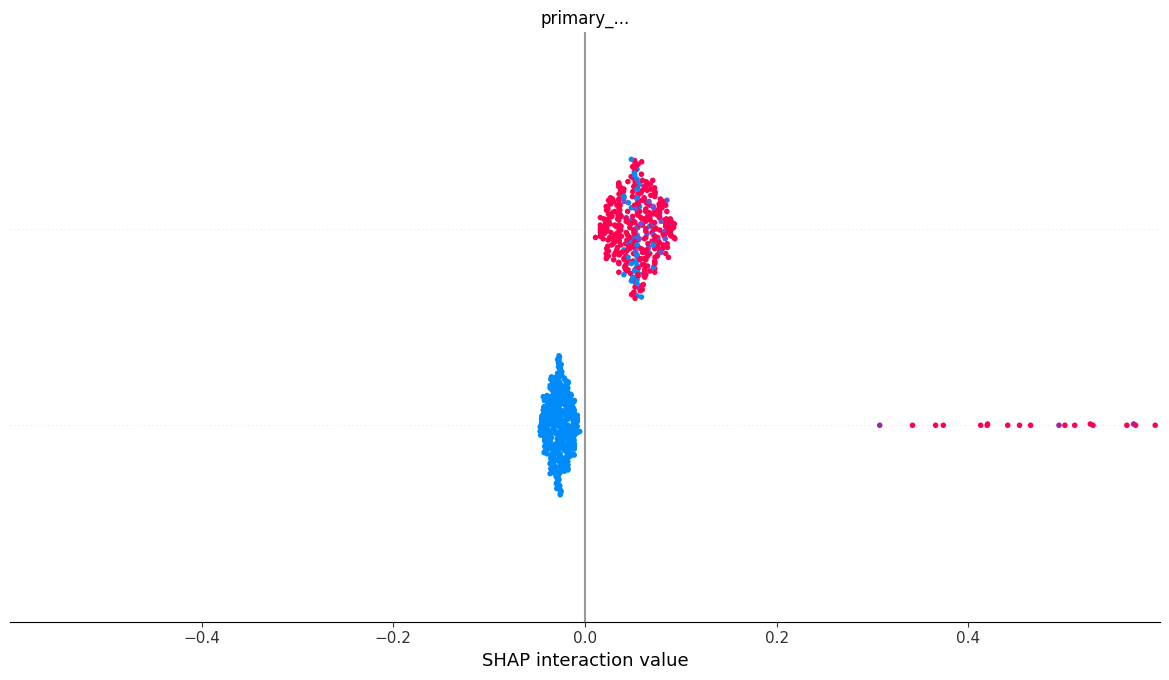

In [22]:
import shap
import matplotlib.pyplot as plt

# Build explainer and SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Determine correct SHAP format
if isinstance(shap_values, list):
    shap_summary = shap_values[1]
else:
    shap_summary = shap_values

# Summary plot
shap.summary_plot(shap_summary, X_test)


## Step 3: Feature Importance (Bar Plot)

Top SHAP Features:

                                              feature  importance
2                       anatomic_neoplasm_subdivision    0.097617
12                        lymphnodes_positive_percent    0.091196
4                                  lymphatic_invasion    0.066377
0                                                race    0.049772
1                     primary_therapy_outcome_success    0.048013
6                             history_of_colon_polyps    0.038435
5                 preoperative_pretreatment_cea_level    0.029709
13                                      margin_status    0.024470
8                                colon_polyps_present    0.016625
14                       additional_radiation_therapy    0.015446
11  loss_expression_of_mismatch_repair_proteins_by...    0.012771
7                    circumferential_resection_margin    0.012324
15                             planned_surgery_status    0.010720
10                   synchronous_colon_cancer_present   

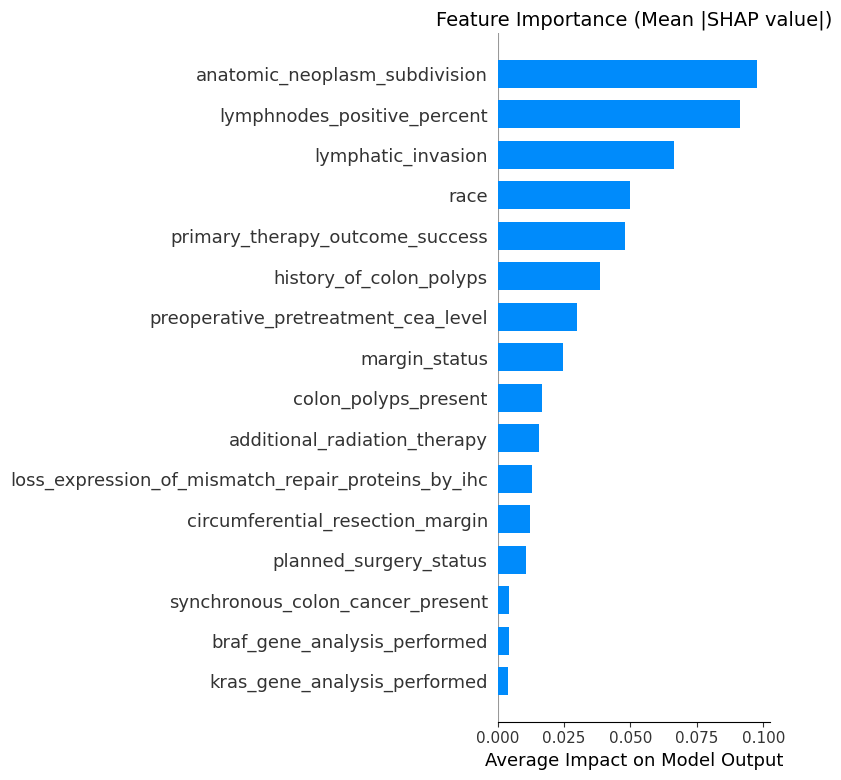

In [23]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Fix the summary
shap_summary = shap_values[:, :, 1]  # extract class 1 only

# 2. Compute importance
shap_values_abs_mean = np.abs(shap_summary).mean(axis=0)

# 3. Label with features
feature_importance = pd.DataFrame({
    'feature': X_test.columns.tolist(),
    'importance': shap_values_abs_mean
}).sort_values(by='importance', ascending=False)

# 4. Print
print("Top SHAP Features:\n")
print(feature_importance)

# 5. Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_summary,
    X_test,
    plot_type="bar",
    max_display=len(X_test.columns),
    show=False
)
plt.title("Feature Importance (Mean |SHAP value|)", fontsize=14)
plt.xlabel("Average Impact on Model Output")
plt.tight_layout()
plt.savefig("../outputs/shap_feature_importance.png", dpi=300)
plt.show()


## Step 4: Individual Force Plot

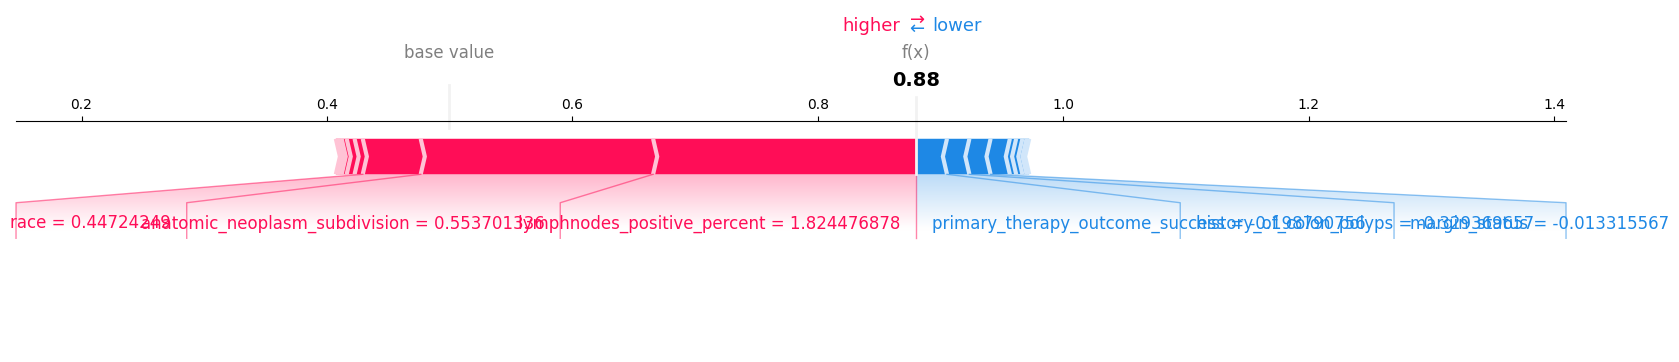

In [24]:
# Choose sample index
i = 0

# Use .force_plot (not shap.plots.force!) with matplotlib=True for static display
shap.force_plot(
    explainer.expected_value[1],        # single float: expected value for class 1
    shap_summary[i],                    # shap values for sample i (1D array)
    X_test.iloc[i],                     # feature values for sample i (pandas Series)
    matplotlib=True                     # forces static rendering instead of JS
)

## SHAP Summary Plot

The SHAP summary plot visualizes the distribution of SHAP values for each feature across all test samples. It captures both:

- The **importance** of a feature (via the spread on the x-axis)
- The **direction of influence** (whether high values increase or decrease cancer prediction)

Each dot is a sample:
- **Color** indicates the feature value (blue = low, pink = high)
- **Position** indicates the SHAP value (left = negative impact, right = positive)

From the plot, we can observe that certain microbial features, when present in higher abundance, consistently push the model toward predicting oral cancer. Others tend to have the opposite effect, acting as protective factors.

---

## Feature Importance – Bar Plot

The bar plot ranks features based on their **mean absolute SHAP value**, showing which bacteria most influenced predictions — regardless of direction (positive or negative).

- Features at the top had the **strongest overall impact** on the model’s decisions.
- This helps identify key microbial signatures potentially associated with oral cancer.

These visualizations are essential for interpreting the model’s behavior and building microbiological insight around prediction patterns.
